# DS 3021 Final Project: Educated Guesses
Liana Kim, Anh Phan, Esther Yun

## Question and Background Information

Through this project, we aim to answer the following question: when countries are clustered based on education enrollment, completion, and performance metrics, do the resulting groups exhibit distinct patterns in unemployment rates? Additionally, do these factors have predictive ability on a country’s unemployment rate?

During the idea development stage of the Data Science Lifecycle, we explored topics such as fitness, travel, and kpop, before focusing on education. Using Google Dataset Search, we selected the Entire World Educational Data by Bhavik Jikadara on Kaggle due to its number of data and variables. The data was compiled from multiple online sources, including UNESCO, which tracks educational indicators.

The dataset contains 29 variables grouped into categories including out of school rates, completion rates, proficiency metrics, literacy rates, birth rate, enrollment rates, and unemployment rate. These variables are reported by education level and gender. Out of school rates indicate the proportion of children not enrolled in school. The completion rate reports the percentage of students who successfully finished a given level of education. The proficiency metrics are based on the subjects of reading and mathematics. The enrollment rates refer to the total number of students enrolled at a given education level as a percentage of the population within the corresponding age group. There are values over 100% in this variable because it includes students outside the official age range, such as those repeating grades or starting early. These variables provide a multidimensional view of each country’s educational profile, alongside the target variable of unemployment rate.

Existing research supports a connection between education and employment outcomes. For example, the Organisation for Economic Co-operation and Development (OECD) found that “employment rates among 25-64 year-olds increase steadily with higher levels of tertiary attainment” and that “among unemployed adults aged 24-64, long-term unemployment is more prevalent among those with lower education attainment.” However, this relationship is not always straightforward. Enrollment does not guarantee completion, and completion does not ensure strong academic performance. Moreover, unemployment is influenced by a wide range of economic and structural factors beyond education, making the relationship complex and not strictly linear.

To address this, we apply kMeans clustering to group countries with similar educational characteristics, allowing us to examine whether distinct unemployment patterns emerge across these groups. We then use linear regression to evaluate whether education related variables have predictive power in explaining unemployment rates.

We now proceed with the remaining stages of the Data Science Lifecycle: data preparation and problem exploration, solution development, and solution deployment.


In [38]:
# Import necessary libraries
import pandas as pd # used for data manipulation
import numpy as np # numerical operations
import sklearn as sk

# Visualization libraries (plotting, statistical visualizations, interactive plots)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing - scaling features (mean = 0, std = 1)
from sklearn.preprocessing import StandardScaler

# Used for model evaluation
from sklearn.model_selection import train_test_split #
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# Clustering evaluation metric
from sklearn.metrics import silhouette_score # measures how well separated clusters are (higher is better)

# Regression evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error
# R-squared: variance explained by the model
# MSE/RMSE: average prediction error

In [39]:
# Read in dataset from GitHub repository
df = pd.read_csv("https://raw.githubusercontent.com/mzk7ue/unemployment_kmeans/refs/heads/main/global_education_data.csv")
df.head()

,Countries and areas,Latitude,Longitude,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
0,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,44,...,13,11,0,0,74,56,32.49,104.0,9.7,11.12
1,Albania,41.153332,20.168331,4,2,6,3,6,1,21,...,0,0,48,58,99,100,11.78,107.0,55.0,12.33
2,Algeria,28.033886,1.659626,0,0,0,0,0,0,0,...,0,0,21,19,98,97,24.28,109.9,51.4,11.70
3,Andorra,42.506285,1.521801,0,0,0,0,0,0,0,...,0,0,0,0,0,0,7.20,106.4,0.0,0.00
4,Angola,11.202692,17.873887,31,39,0,0,0,0,0,...,0,0,0,0,0,0,40.73,113.5,9.3,6.89


In [40]:
# Check column names
df.columns

Index(['Countries and areas', 'Latitude ', 'Longitude',
       'OOSR_Pre0Primary_Age_Male', 'OOSR_Pre0Primary_Age_Female',
       'OOSR_Primary_Age_Male', 'OOSR_Primary_Age_Female',
       'OOSR_Lower_Secondary_Age_Male', 'OOSR_Lower_Secondary_Age_Female',
       'OOSR_Upper_Secondary_Age_Male', 'OOSR_Upper_Secondary_Age_Female',
       'Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
       'Completion_Rate_Lower_Secondary_Male',
       'Completion_Rate_Lower_Secondary_Female',
       'Completion_Rate_Upper_Secondary_Male',
       'Completion_Rate_Upper_Secondary_Female',
       'Grade_2_3_Proficiency_Reading', 'Grade_2_3_Proficiency_Math',
       'Primary_End_Proficiency_Reading', 'Primary_End_Proficiency_Math',
       'Lower_Secondary_End_Proficiency_Reading',
       'Lower_Secondary_End_Proficiency_Math',
       'Youth_15_24_Literacy_Rate_Male', 'Youth_15_24_Literacy_Rate_Female',
       'Birth_Rate', 'Gross_Primary_Education_Enrollment',
       'Gross_Tertiary_Edu

In [41]:
# Removing leading and trailing whitespace from all column names (ex. Latitude)
# Helps prevent referencing errors
df.columns = df.columns.str.strip()

# Check
df.columns

Index(['Countries and areas', 'Latitude', 'Longitude',
       'OOSR_Pre0Primary_Age_Male', 'OOSR_Pre0Primary_Age_Female',
       'OOSR_Primary_Age_Male', 'OOSR_Primary_Age_Female',
       'OOSR_Lower_Secondary_Age_Male', 'OOSR_Lower_Secondary_Age_Female',
       'OOSR_Upper_Secondary_Age_Male', 'OOSR_Upper_Secondary_Age_Female',
       'Completion_Rate_Primary_Male', 'Completion_Rate_Primary_Female',
       'Completion_Rate_Lower_Secondary_Male',
       'Completion_Rate_Lower_Secondary_Female',
       'Completion_Rate_Upper_Secondary_Male',
       'Completion_Rate_Upper_Secondary_Female',
       'Grade_2_3_Proficiency_Reading', 'Grade_2_3_Proficiency_Math',
       'Primary_End_Proficiency_Reading', 'Primary_End_Proficiency_Math',
       'Lower_Secondary_End_Proficiency_Reading',
       'Lower_Secondary_End_Proficiency_Math',
       'Youth_15_24_Literacy_Rate_Male', 'Youth_15_24_Literacy_Rate_Female',
       'Birth_Rate', 'Gross_Primary_Education_Enrollment',
       'Gross_Tertiary_Educ

In [42]:
# Drop Latitude and Longitude since they are irrelevant to our clustering.
X = df.drop(columns=['Latitude', 'Longitude'])

In [43]:
# Check for missing values in dataset
X.isna().sum()

# Observation: There are no missing values.

Countries and areas                        0
OOSR_Pre0Primary_Age_Male                  0
OOSR_Pre0Primary_Age_Female                0
OOSR_Primary_Age_Male                      0
OOSR_Primary_Age_Female                    0
OOSR_Lower_Secondary_Age_Male              0
OOSR_Lower_Secondary_Age_Female            0
OOSR_Upper_Secondary_Age_Male              0
OOSR_Upper_Secondary_Age_Female            0
Completion_Rate_Primary_Male               0
Completion_Rate_Primary_Female             0
Completion_Rate_Lower_Secondary_Male       0
Completion_Rate_Lower_Secondary_Female     0
Completion_Rate_Upper_Secondary_Male       0
Completion_Rate_Upper_Secondary_Female     0
Grade_2_3_Proficiency_Reading              0
Grade_2_3_Proficiency_Math                 0
Primary_End_Proficiency_Reading            0
Primary_End_Proficiency_Math               0
Lower_Secondary_End_Proficiency_Reading    0
Lower_Secondary_End_Proficiency_Math       0
Youth_15_24_Literacy_Rate_Male             0
Youth_15_2

In [44]:
# Exploratory Data Analysis: Initial Summary Statistics (mean, std, etc.)
X.describe()

,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,OOSR_Upper_Secondary_Age_Female,Completion_Rate_Primary_Male,Completion_Rate_Primary_Female,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,...,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,19.658416,19.282178,5.282178,5.569307,8.707921,8.831683,20.292079,19.975248,41.722772,42.128713,...,10.717822,10.376238,25.787129,24.450495,35.801980,35.084158,18.914010,94.942574,34.392574,6.000000
std,25.007604,25.171147,9.396442,10.383092,13.258203,14.724717,21.485592,23.140376,42.162708,43.099714,...,24.866101,22.484423,33.181384,31.965467,45.535186,45.249643,10.828184,29.769338,29.978206,5.273136
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.355000,97.200000,9.000000,2.302500
50%,9.000000,7.000000,1.000000,1.000000,2.000000,2.000000,15.000000,12.000000,37.500000,33.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.550000,101.850000,24.850000,4.585000
75%,31.000000,30.000000,6.000000,6.750000,12.750000,10.750000,32.750000,30.000000,87.500000,92.000000,...,0.000000,0.000000,56.750000,50.750000,94.000000,96.750000,27.692500,107.300000,59.975000,8.655000
max,96.000000,96.000000,58.000000,67.000000,61.000000,70.000000,84.000000,89.000000,100.000000,100.000000,...,99.000000,89.000000,89.000000,94.000000,100.000000,100.000000,46.080000,142.500000,136.600000,28.180000


In [45]:
# Take a look at the columns again.
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries and areas                      202 non-null    str    
 1   OOSR_Pre0Primary_Age_Male                202 non-null    int64  
 2   OOSR_Pre0Primary_Age_Female              202 non-null    int64  
 3   OOSR_Primary_Age_Male                    202 non-null    int64  
 4   OOSR_Primary_Age_Female                  202 non-null    int64  
 5   OOSR_Lower_Secondary_Age_Male            202 non-null    int64  
 6   OOSR_Lower_Secondary_Age_Female          202 non-null    int64  
 7   OOSR_Upper_Secondary_Age_Male            202 non-null    int64  
 8   OOSR_Upper_Secondary_Age_Female          202 non-null    int64  
 9   Completion_Rate_Primary_Male             202 non-null    int64  
 10  Completion_Rate_Primary_Female           202 non-null    int6

After removing Latitude and Longitude, we decided to keep the remaining variables for the first clustering model. This model will serve as our baseline kMeans clustering approach, allowing us to observe how the full feature behaves without reductions/optimizations being made.

Subsequent models will introduce different feature manipulations and selections made to evaluate whether clustering quality can be improved.

In [46]:
# kMeans Clustering Pipeline (kMeans Model 1)

# Drop non-numeric columns
features = X.drop(columns=["Countries and areas"])

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# KMeans: performs clustering on scaled data with 3 clusters and a random state of 42 for reproducibility
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])

# Fit pipeline to data
pipe.fit(features)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final 

In [47]:
# Model 1 KMeans Clustering Results

# Extracts fitted KMeans model from pipeline
kmeans_m1 = pipe.named_steps['kmeans']

# Cluster centers: mean position of each cluster in feature space
print(f"Cluster centers: {kmeans_m1.cluster_centers_}")

# Cluster assignment for each data point
print(f"Cluster labels: {kmeans_m1.labels_}")

# Inertia: within cluster sum of squares (wcss)
print(f"Inertia: {kmeans_m1.inertia_}")

Cluster centers: [[-1.75607454e-01 -1.67779410e-01 -1.94581765e-01 -2.31974204e-01
  -2.97167532e-01 -3.38405229e-01 -2.46272188e-01 -2.89545256e-01
   1.11616469e+00  1.12154589e+00  1.15431472e+00  1.17706239e+00
   1.08779350e+00  1.09651010e+00  3.36403091e-03 -4.19888275e-02
   1.12724303e-01  1.96865138e-01 -1.27425760e-01 -1.69193309e-01
   3.51105240e-01  3.60608201e-01  9.91147968e-02  1.57493919e-01
  -5.66004324e-02  4.01003480e-01]
 [-3.98759458e-01 -4.08177977e-01 -3.56095047e-01 -3.76798758e-01
  -4.35790260e-01 -4.13673382e-01 -4.69843935e-01 -4.60064970e-01
  -9.59793867e-01 -9.53796825e-01 -8.82029466e-01 -8.60326340e-01
  -7.79377472e-01 -7.47957508e-01  1.38871623e-01  8.24949332e-02
   1.52124865e-03 -5.69019894e-02  3.86434373e-01  4.50021770e-01
  -2.44416766e-01 -2.33994709e-01 -5.67502090e-01 -1.46610649e-01
   4.01013447e-01 -2.57981458e-01]
 [ 1.21330220e+00  1.22040339e+00  1.15146103e+00  1.26535077e+00
   1.51542964e+00  1.53989452e+00  1.50043879e+00  1.55

In [48]:
# 3D Visualization of Model 1 Clusters

# Copy original dataset
X_plot = X.copy()

# Predict cluster assignments using trained KMeans pipeline
X_plot['Cluster'] = pipe.predict(features)

# Interactive 3D scatter plot
fig = px.scatter_3d(
    X_plot, x="Lower_Secondary_End_Proficiency_Reading", y="Lower_Secondary_End_Proficiency_Math", z="Gross_Tertiary_Education_Enrollment", # 3 chosen variables
    color="Unemployment_Rate", # color represents unemployment rate
    symbol='Cluster', # symbol represent cluster assignment
    hover_data=["Countries and areas"]) # hover show check which point is which Country or area
fig.show()

The 3D visualization displays the clustering structure produced by the KMeans model using education-related indicators.

Three variables were selected for visualization:
- Lower Secondary Reading Proficiency
- Lower Secondary Math Proficiency
- Gross Tertiary Education Enrollment

These variables were chosen because we collectively felt like they best represent key educational measures and allowed for interpretable separation of countries in 3D feature space.

Clusters are represented by different symbols, while unemployment rate is mapped to color to help identify whether unemployment rates align with educational groupings.

In [49]:
# Calculate variance explained for KMeans Model 1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Total sum of squares (TSS) - measures total variance in dataset
# features_scaled.mean() = 0 because of standardization
total = (features_scaled - features_scaled.mean(axis=0))**2
tss = np.sum(total)

# Between-cluster sum of squares (BSS) - measures variance explained by clustering structure
between_SSE = (tss - kmeans_m1.inertia_)

# Variance explained - proportion of total variance explained by cluster separation
var_explained = between_SSE / tss
print(f"Variance Explained: {var_explained:.4f} or {var_explained*100:.2f}%")

Variance Explained: 0.3786 or 37.86%


37.86% of the total variance in the dataset is explained by our KMeans clustering model 1.

In [50]:
# Calculate silhouette score - KMeans Model 1

# This evaluates how well each data point fits within its assigned cluster compared to other closters
# Considers both cohesion (similarity within clusters) and separation (distance from other clusters)
# values: 1 - well separated clusters, 0 - overlapping clusters

ss = silhouette_score(features_scaled, kmeans_m1.labels_)
print(f"Silhouette score: {ss}")

Silhouette score: 0.2540034039935471


A silhouette score of 0.254 indicates weak to moderate cluster separation. It suggests that while the KMeans model identifies some structure in the data, the clusters are not well defined.

This is also consistent with the variance explained (37.86%), indicating that the selected features capture partial but not strong segmentation between countries.

In [51]:
# Elbow Method for optimal k selection
# Evaluates different values of k by measuring the WCSS - lower WCSS indicates tighter cluster

wcss = []

# Loop over different cluster sizes (k = 1 to 10)
for i in range(1, 11):

  # Build pipeline
  # StandardScaler: standardizes features (mean = 0, std = 1)
  # KMeans: performs clustering on scaled data given number of clusters (i) and a random state of 42 for reproducibility
  km = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data
  km.fit(features_scaled)

  # Store WCSS for each k
  wcss.append(km.named_steps['kmeans'].inertia_)

# DataFrame for visualization
elbow_data_Dem = pd.DataFrame({"k": range(1, 11), "wcss": wcss})

# Plot elbow curve
fig = px.line(elbow_data_Dem, x="k", y="wcss", title="Elbow Method using WCSS (Model 1)")
fig.show()

The elbow method indicates an optimal number of clusters at k = 3, where the rate of decrease in WCSS significantly slows down. This suggests that three clusters provide a good balance between model simplicity and cluster compactness.

In [52]:
# Silhoutte Score for optimal k

ss = []
# Loop over different cluster sizes (k = 2 to 10)
for i in range(2, 11): # silhouette score cannot run for k=1

  # Build pipeline
  km = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data (scaled)
  km.fit(features_scaled)

  # Extract cluster labels assigned to each observation
  labels = km.named_steps['kmeans'].labels_

  # Compute silhouette score
  ss.append(silhouette_score(StandardScaler().fit_transform(features_scaled), labels))

# Store results for visualization
elbow_data_Dem = pd.DataFrame({"k": range(2, 11), "ss": ss})

# Plot silhouette scores across different k values
fig = px.line(elbow_data_Dem, x="k", y="ss", title="Elbow Method using Silhouette Score (Model 1)")
fig.show()

The silhouette score reaches its maximum at k = 3, indicating the best trade-off between cluster cohesion and separation. This suggests that three clusters provide the most well-defined grouping structure in the data. Since the KMeans model was already estimated using k = 3, no further adjustment was made.

From the clustering visualization, one cluster appears to be a lighter color compared to other clusters (indicating higher unemployment rates). This pattern suggests that there is a potential relationship between the variables and unemployment outcomes.

To further investigate this relationship, we proceed to a regression analysis. For now, we will keep all the variables for linear regression to evaluate their overall predictive power for unemployment rates.

Text(0.5, 1.0, 'Unemployment Rate Distribution')

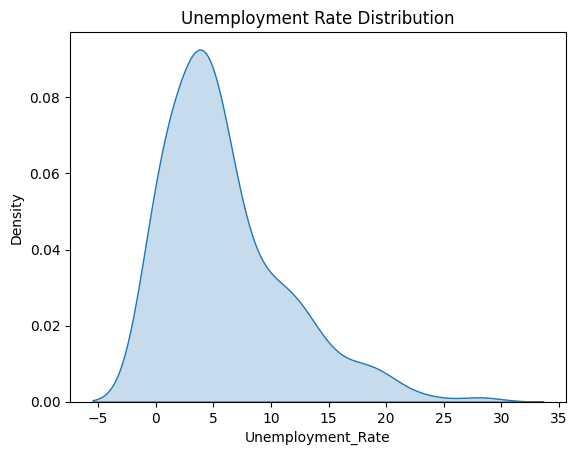

In [53]:
# KDE Plot of the Response Variable
sns.kdeplot(data = X, x = 'Unemployment_Rate', fill = True)
plt.title('Unemployment Rate Distribution')

Although there is a slight right skew in the response variable, it is still suitable for linear regression since it does not have too many extreme values, and it spands a wide range.

In [54]:
# Split data for Linear Regression Model 1

# Define features for linear regression - remove non-predictive identifier and target variable
X_lr = X.drop(columns=["Countries and areas", "Unemployment_Rate"])

# Define target variable
Y_lr = X["Unemployment_Rate"]

# Split data into training and testing sets (80% training used to fit model, 20% testing used to evaluate)
X_train, X_test, Y_train, Y_test = train_test_split(X_lr, Y_lr, test_size=0.2, random_state=42)


In [55]:
# Linear Regression Model 1

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# LinearRegression: fits linear relationship between features and target with a base level (fit_intercept)
linear_m1 = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression(fit_intercept=True))
])

# Fit model on training data
linear_m1.fit(X_train, Y_train)

# Generate predictions on test set
Y_pred = linear_m1.predict(X_test)

In [56]:
# Evaluation of Linear Regression Model 1

# R-squared: proportion of variance in unemployment rate explained by the model
r2 = r2_score(Y_test, Y_pred)

# Mean Squared Error: average squared difference between actual and predicted values
mse = mean_squared_error(Y_test, Y_pred)

# Root Mean Squared Error: used for interpretability (same units as target)
rmse = np.sqrt(mse)

print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Access model from pipeline
linear1 = linear_m1.named_steps['linear']

# Represent relationship between each feature and unemployment rate
print(f"Coefficients: {linear1.coef_}")

# Represents predicted unemployment rate when all predictors are 0 (scaled)
print(f"Intercept: {linear1.intercept_}")

R^2: -0.0144
RMSE: 6.0427
Coefficients: [ 9.68349995e-01  5.67655622e-01  1.63561195e+00 -1.30899533e+00
  1.09834251e+00 -9.33844183e-01 -2.45126637e+00  1.64143827e+00
  4.85048705e+00 -5.54927983e+00 -6.85609673e+00  9.00731754e+00
  3.49224486e-01 -5.30056992e-01 -3.17610338e-01 -4.95156524e-01
 -7.08845817e-01  4.42965732e-01 -4.31229644e-03 -3.61318135e-01
  3.61616745e+00 -3.49563695e+00  1.13034267e-01  8.31479255e-01
  1.88736955e+00]
Intercept: 5.8450931677018625


Oh no! Our R-squared value is NEGATIVE (-0.0144). This means that our model has no meaningful predictive power and fails to explain any variation in unemployment rates. Also, the RMSE is 6.0427, which suggests that we have relatively large prediction errors.

These results suggest that the full set of variables do not provide meaningful predictive power for unemployment rates. We think that this may be because of multicollinearity and weak relationships between predictors and the target variable overall.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

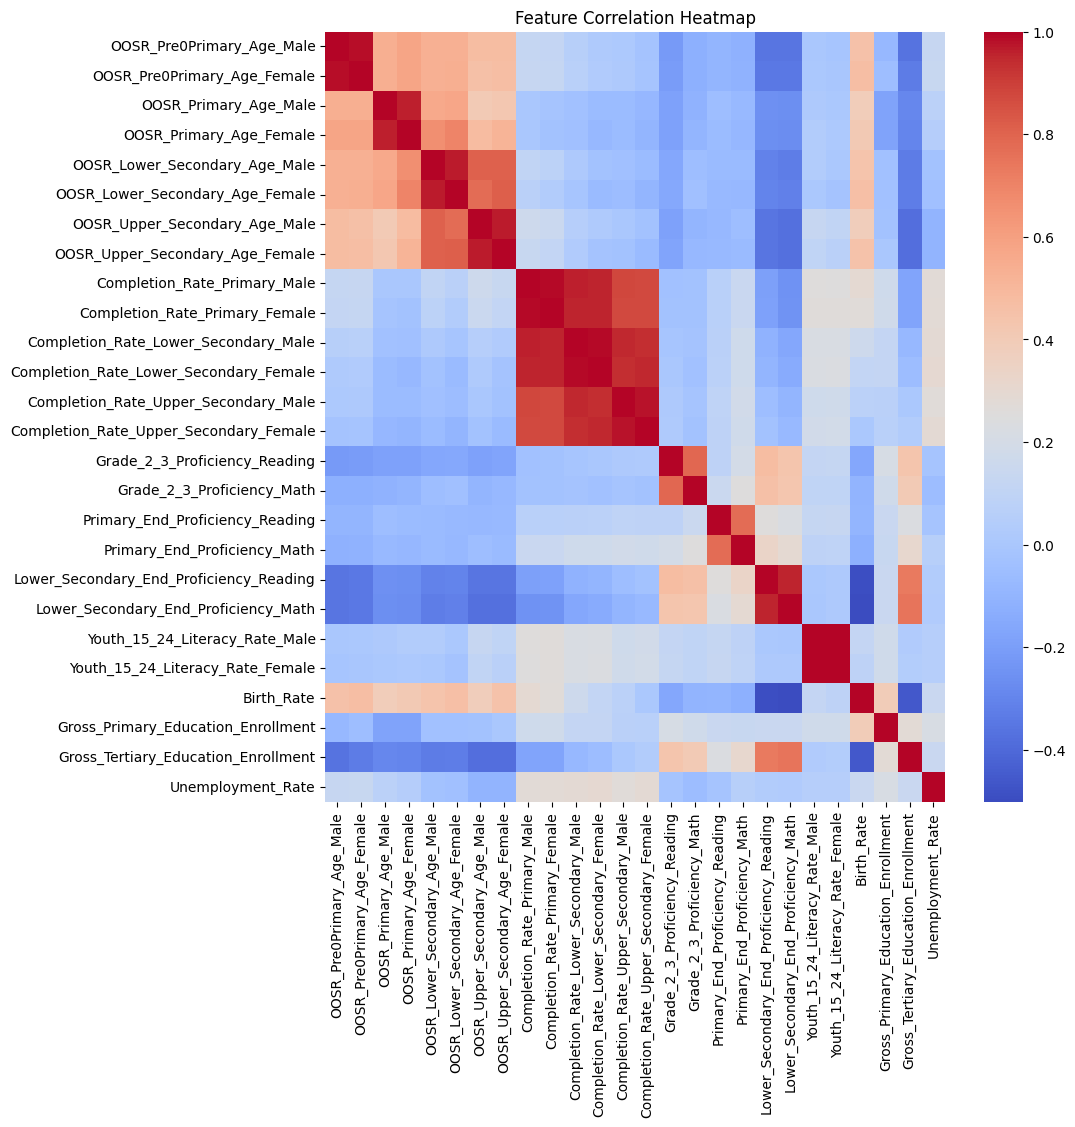

In [57]:
# Exploratory Data Analysis (Linear Regression Model 1): Correlation matrix for multicollinearity

# Only numeric features
X_cleaned = X.drop(columns=["Countries and areas"])

# Correlation heatmap
plt.figure(figsize=(10, 10))

# Compute pairwise correlations between all features
# Heatmap visualizes strength and direction of the relationships: red - strong positive correlation, blue - strong negative, white - weak/no correlation
sns.heatmap(X_cleaned.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

By looking at this heatmap, we found that male and female variables are highly correlated.

So, we decided to combine male and female variables into a single averaged feature to reduce multicollinearity and redundancy (preserving information but simplifying variables).

In [58]:
# Combine Male and Female Variables (this will be Linear Regression Model 2)

# Copy of dataset
X_new = X.copy()

# Store column names (used for iteration)
cols = X_new.columns

# Find all columns ending in _Male
male_cols = [col for col in cols if col.endswith('_Male')]

# Loop through each male column and match with corresponding female column
for male_col in male_cols:
    # Extract base variable name - remove '_Male'
    base = male_col[:-5]

    # Female column name
    female_col = base + '_Female'

    # Check if matching female column exists
    if female_col in cols:
        # Create averaged column: combines male/female values
        X_new[base + '_Avg'] = (X_new[male_col] + X_new[female_col]) / 2

        # Drop original columns
        X_new.drop(columns=[male_col, female_col], inplace=True)

X_new.head()

,Countries and areas,Grade_2_3_Proficiency_Reading,Grade_2_3_Proficiency_Math,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate,OOSR_Pre0Primary_Age_Avg,OOSR_Primary_Age_Avg,OOSR_Lower_Secondary_Age_Avg,OOSR_Upper_Secondary_Age_Avg,Completion_Rate_Primary_Avg,Completion_Rate_Lower_Secondary_Avg,Completion_Rate_Upper_Secondary_Avg,Youth_15_24_Literacy_Rate_Avg
0,Afghanistan,22,25,13,11,0,0,32.49,104.0,9.7,11.12,0.0,0.0,0.0,56.5,53.5,37.5,23.0,65.0
1,Albania,0,0,0,0,48,58,11.78,107.0,55.0,12.33,3.0,4.5,3.5,18.0,95.0,97.5,78.0,99.5
2,Algeria,0,0,0,0,21,19,24.28,109.9,51.4,11.70,0.0,0.0,0.0,0.0,93.0,57.0,29.5,97.5
3,Andorra,0,0,0,0,0,0,7.20,106.4,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Angola,0,0,0,0,0,0,40.73,113.5,9.3,6.89,35.0,0.0,0.0,0.0,60.0,37.0,19.5,0.0


In [59]:
# Copy of new combined dataset
X_scaled_new = X_new.copy()
cols = X_new.columns[1:] # store column names for iteration (exclude Countries and areas)

# Apply scaling to all numeric columns
# .iloc[:,1:] used to exclude Countries and areas
X_scaled_new[cols] = X_scaled_new[cols].astype(float)

scaler = StandardScaler()
X_scaled_new[cols] = scaler.fit_transform(X_new[cols])

X_scaled_new.head()

,Countries and areas,Grade_2_3_Proficiency_Reading,Grade_2_3_Proficiency_Math,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate,OOSR_Pre0Primary_Age_Avg,OOSR_Primary_Age_Avg,OOSR_Lower_Secondary_Age_Avg,OOSR_Upper_Secondary_Age_Avg,Completion_Rate_Primary_Avg,Completion_Rate_Lower_Secondary_Avg,Completion_Rate_Upper_Secondary_Avg,Youth_15_24_Literacy_Rate_Avg
0,Afghanistan,0.000569,0.254713,0.092007,0.027811,-0.779087,-0.766804,1.256879,0.305009,-0.825731,0.973371,-0.781068,-0.554967,-0.633735,1.648311,0.272607,0.122756,0.004220,0.653289
1,Albania,-0.631853,-0.587658,-0.432092,-0.462632,0.671101,1.052162,-0.660474,0.406035,0.689121,1.203407,-0.660720,-0.094689,-0.380814,-0.096709,1.250051,1.742578,1.879410,1.415833
2,Algeria,-0.631853,-0.587658,-0.432092,-0.462632,-0.144630,-0.170936,0.496789,0.503692,0.568736,1.083636,-0.781068,-0.554967,-0.633735,-0.912562,1.202946,0.649198,0.225833,1.371627
3,Andorra,-0.631853,-0.587658,-0.432092,-0.462632,-0.779087,-0.766804,-1.084495,0.385830,-1.150103,-1.140670,-0.781068,-0.554967,-0.633735,-0.912562,-0.987472,-0.889632,-0.779951,-0.783388
4,Angola,-0.631853,-0.587658,-0.432092,-0.462632,-0.779087,-0.766804,2.019747,0.624923,-0.839107,0.169199,0.622987,-0.554967,-0.633735,-0.912562,0.425701,0.109258,-0.115111,-0.783388


Text(0.5, 1.0, 'Feature Correlation Heatmap')

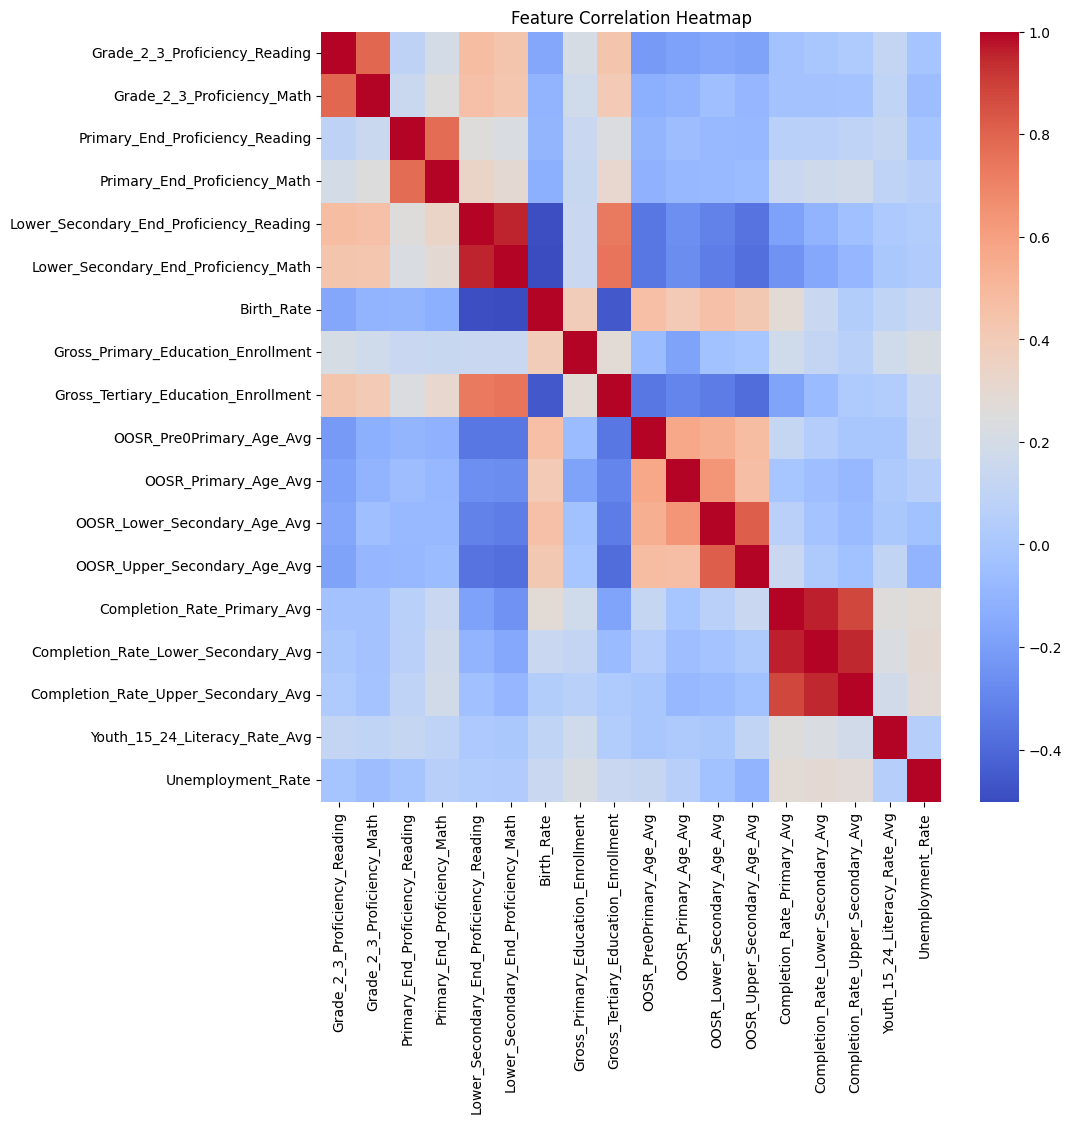

In [60]:
# Correlation Matrix after combining

# Remove Countries and areas
X_cleaned_new = X_scaled_new.drop(columns = ['Countries and areas'])

# Reorder columns to place target variable at the end
cols = [c for c in X_cleaned_new.columns if c != "Unemployment_Rate"] + ["Unemployment_Rate"]
X_cleaned_new = X_cleaned_new[cols]

# Plot heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(X_cleaned_new.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

In [61]:
# Split new data for Linear Regression Model 2

# Define features for linear regression (these will be the combined male and female variables) - remove non-predictive identifier and target variable
X_l2 = X_new.drop(columns=["Countries and areas", "Unemployment_Rate"])

# Define target variable
Y_l2 = X_new["Unemployment_Rate"]

# Split data into training and testing sets (80% training used to fit model, 20% testing used to evaluate)
X_train_2, X_test_2, Y_train_2, Y_test_2 = train_test_split(X_l2, Y_l2, test_size=0.2, random_state=42)

In [62]:
# Linear Regression Model 2

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# LinearRegression: fits linear relationship between features and target with a base level (fit_intercept)
linear_m2 = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression(fit_intercept=True))
])

# Fit model on training data
linear_m2.fit(X_train_2, Y_train_2)

# Generate predictions on test set
Y_pred_2 = linear_m2.predict(X_test_2)

In [63]:
# Evaluation of Linear Regression Model 2

# R-squared: proportion of variance in unemployment rate explained by the model
r2_2 = r2_score(Y_test_2, Y_pred_2)

# Mean Squared Error: average squared difference between actual and predicted values
mse_2 = mean_squared_error(Y_test_2, Y_pred_2)

# Root Mean Squared Error: used for interpretability (same units as target)
rmse_2 = np.sqrt(mse_2)

print(f"R^2: {r2_2:.4f}")
print(f"RMSE: {rmse_2:.4f}")

# Access model from pipeline
linear2 = linear_m2.named_steps['linear']

# Represent relationship between each feature and unemployment rate
print(f"Coefficients: {linear2.coef_}")

# Represents predicted unemployment rate when all predictors are 0 (scaled)
print(f"Intercept: {linear2.intercept_}")

R^2: 0.0066
RMSE: 5.9799
Coefficients: [-0.3058984  -0.59145838 -0.70208244  0.39881478 -0.13122801 -0.37365007
 -0.1404868   0.9813647   1.9796377   1.27449937  0.68237743  0.03080278
 -1.0242398   0.35738671  0.67952233  0.30344865  0.18041037]
Intercept: 5.845093167701863


Oh man! The R-squared for Model 2 (0.0066) barely improved (-_-)

Multicollinearity may not have been the primary issue.

Despite the limited improvement in regression performance, the feature engineering may still influence clustering results. Therefore, we proceeded to re-evaluate the KMeans clustering using the transformed variables to determine whether clearer group structures could be seen.

In [64]:
# KMeans Clustering Pipeline (KMeans Model 2)

# Drop non-numeric columns
features_2 = X_new.drop(columns=["Countries and areas"])

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# KMeans: performs clustering on scaled data with 3 clusters and a random state of 42 for reproducibility
kmeans_m2 = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])

# Fit pipeline to data
kmeans_m2.fit(features_2)

# Extract cluster assignments for each observation
labels_2 = kmeans_m2.named_steps['kmeans'].labels_

# Copy dataset for plotting
X_plot_2 = X_new.copy()

# Add cluster labels
X_plot_2['Cluster'] = labels_2

# Interactive 3D scatter plot
fig = px.scatter_3d(
    X_plot_2, x="Lower_Secondary_End_Proficiency_Reading", y="Lower_Secondary_End_Proficiency_Math", z="Gross_Tertiary_Education_Enrollment", # 3 chosen variables
    color="Unemployment_Rate", # color represents unemployment rate
    symbol='Cluster', # symbol represent cluster assignment
    hover_data=["Countries and areas"]) # hover shows which point is which Country or area
fig.show()

In [65]:
# Elbow Method for optimal k selection (Model 2)
# Evaluates different values of k by measuring the WCSS - lower WCSS indicates tighter cluster

wcss_2 = []

# Loop over different cluster sizes (k = 1 to 11)
for i in range(1, 12):

  # Build pipeline
  # StandardScaler: standardizes features (mean = 0, std = 1)
  # KMeans: performs clustering on scaled data given number of clusters (i) and a random state of 42 for reproducibility
  km2 = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data
  km2.fit(features_2)

  # Store WCSS for each k
  wcss_2.append(km2.named_steps['kmeans'].inertia_)

# DataFrame for visualization
elbow_data_Dem2 = pd.DataFrame({"k": range(1, 12), "wcss": wcss_2})

# Plot elbow curve
fig = px.line(elbow_data_Dem2, x="k", y="wcss", title="Elbow Method using WCSS")
fig.show()

# Elbow is not clear k = 7


The elbow curve for Model 2 does not show a clearly defined inflection point. A weak bend is observed at k = 7.

In [66]:
# Silhoutte Score for optimal k (Model 2)

ss_2 = []

# Loop over different cluster sizes (k = 2 to 11)
for i in range(2, 12): # silhouette score cannot run for k=1

  # Build pipeline
  km2 = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data (scaled)
  km2.fit(features_2)

  # Extract cluster labels assigned to each observation
  labels = km2.named_steps['kmeans'].labels_

  # Compute silhouette score
  ss_2.append(silhouette_score(StandardScaler().fit_transform(features_2), labels))

# Store results for visualization
elbow_data_Dem2 = pd.DataFrame({"k": range(2, 12), "ss": ss_2})

# Plot silhouette scores across different k values
fig = px.line(elbow_data_Dem2, x="k", y="ss", title="Elbow Method using Silhouette Score")
fig.show()

# Highest k = 10

The highest silhouette score occurs at k = 10, suggesting that this is the level where we will find the most distinct clustering structure.

In [67]:
# Let's evaluate the model at k = 10
kmeans_m10 = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=10, random_state=42))
])

# Fit pipeline to data
kmeans_m10.fit(features_2)

# Extract cluster assignments for each observation
labels_2 = kmeans_m10.named_steps['kmeans'].labels_

# Copy dataset for plotting
X_plot_10 = X_new.copy()

# Add cluster labels
X_plot_10['Cluster'] = labels_2

# Interactive 3D scatter plot
fig = px.scatter_3d(
    X_plot_10, x="Lower_Secondary_End_Proficiency_Reading", y="Lower_Secondary_End_Proficiency_Math", z="Gross_Tertiary_Education_Enrollment", # 3 chosen variables
    color="Unemployment_Rate", # color represents unemployment rate
    symbol='Cluster', # symbol represent cluster assignment
    hover_data=["Countries and areas"]) # hover shows which point is which Country or area
fig.show()

In [68]:
# Clustering evaluation for k = 10

# Standardize features
scaled2 = StandardScaler().fit_transform(features_2)

# Fit KMeans with optimal k based on silhouette score (k = 10)
kmeans_best = KMeans(n_clusters=10, random_state=42).fit(scaled2)

# Extract cluster labels
labels_best = kmeans_best.labels_

# Total sum of squares (TSS)
total_2 = (scaled2 - scaled2.mean(axis=0))**2
tss_2 = np.sum(total_2)

# Between-cluster sum of squares (BSS)
between_SSE_2 = (tss_2 - kmeans_best.inertia_)

# Variance explained (BSS / TSS)
var_explained2 = between_SSE_2 / tss_2
print(f"Variance Explained: {var_explained2:.4f} or {var_explained2*100:.2f}%")

# Silhouette score
ss_2 = silhouette_score(scaled2, labels_best)
print(f"Silhouette score: {ss_2}")

Variance Explained: 0.6366 or 63.66%
Silhouette score: 0.24674189680766614


Model 2 with k = 10 clusters achieves a variance explained of 63.66%, indicating that a substantial proportion of the variability in the dataset is captured by the clustering. This is an improvement from Model 1 (37%), suggesting that the feature engineering process (combining male and female variables) did enhance the overall structure.

However, the silhouette score is 0.247, which is relatively low, indicating that the clusters are still not well separated and overlap quite a bit.

The heatmap of the combined features showed some variables with relative correlations with unemployment rate, which we will now pick out and further analyze.

In [69]:
# Linear Regression Model 3

# Define selected features for linear regression
X_l3 = X_new[['Completion_Rate_Primary_Avg', 'Completion_Rate_Lower_Secondary_Avg', 'Completion_Rate_Upper_Secondary_Avg']]

# Define target variable
y_l3 = X_new['Unemployment_Rate']

# Split data into training and testing sets (80% training used to fit model, 20% testing used to evaluate)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_l3, y_l3, test_size=0.2, random_state=42)

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# LinearRegression: fits linear relationship between features and target with a base level (fit_intercept)
linear_m3 = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression(fit_intercept=True))
])

# Fit model on training data
linear_m3.fit(X_train_3, y_train_3)

# Generate predictions on test set
y_pred_3 = linear_m3.predict(X_test_3)

In [70]:
# Evaluation of Linear Regression Model 3

# R-squared: proportion of variance in unemployment rate explained by the model
r2_3 = r2_score(y_test_3, y_pred_3)

# Mean Squared Error: average squared difference between actual and predicted values
mse_3 = mean_squared_error(y_test_3, y_pred_3)

# Root Mean Squared Error: used for interpretability (same units as target)
rmse_3 = np.sqrt(mse_3)

print(f"R^2: {r2_3:.4f}")
print(f"RMSE: {rmse_3:.4f}")

# Access model from pipeline
linear3 = linear_m3.named_steps['linear']

# Represent relationship between each feature and unemployment rate
print(f"Coefficients: {linear3.coef_}")

# Represents predicted unemployment rate when all predictors are 0 (scaled)
print(f"Intercept: {linear3.intercept_}")

R^2: 0.0785
RMSE: 5.7593
Coefficients: [-0.9634737   2.11679869  0.20117406]
Intercept: 5.845093167701863


Yay...? The R-squared for Linear Regression Model 3 is higher than the previous two. However, this is still not ideal for practical purposes. Still, let's check if this improved clustering.

In [71]:
# KMeans Clustering Pipeline (KMeans Model 3)

# Select columns for model
features3 = X_new[['Completion_Rate_Primary_Avg', 'Completion_Rate_Lower_Secondary_Avg', 'Completion_Rate_Upper_Secondary_Avg']]

# Build pipeline
# StandardScaler: standardizes features (mean = 0, std = 1)
# KMeans: performs clustering on scaled data with 3 clusters and a random state of 42 for reproducibility
kmeans_m3 = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])

# Fit pipeline to data
kmeans_m3.fit(features3)

# Extract cluster assignments for each observation
labels_3 = kmeans_m3.named_steps['kmeans'].labels_

# Copy dataset for plotting
X_plot_3 = X_new.copy()

# Add cluster labels
X_plot_3['Cluster'] = labels_3

# Interactive 3D scatter plot
fig = px.scatter_3d(
    X_plot_3, x="Completion_Rate_Primary_Avg", y="Completion_Rate_Lower_Secondary_Avg", z="Completion_Rate_Upper_Secondary_Avg", # 3 chosen variables
    color="Unemployment_Rate", # color represent unemployment rate
    symbol='Cluster', # symbol represent cluster assignment
    hover_data=["Countries and areas"]) # hover shows which point is which Country or area
fig.show()

In [72]:
# Elbow Method for optimal k selection (Model 3)
# Evaluates different values of k by measuring the WCSS - lower WCSS indicates tighter cluster

wcss_3 = []

# Loop over different cluster sizes (k = 1 to 10)
for i in range(1, 11):

  # Build pipeline
  # StandardScaler: standardizes features (mean = 0, std = 1)
  # KMeans: performs clustering on scaled data given number of clusters (i) and a random state of 42 for reproducibility
  km3 = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data
  km3.fit(features3)

  # Store WCSS for each k
  wcss_3.append(km3.named_steps['kmeans'].inertia_)

# DataFrame for visualization
elbow_data_Dem3 = pd.DataFrame({"k": range(1, 11), "wcss": wcss_3})

# Plot elbow curve
fig = px.line(elbow_data_Dem3, x="k", y="wcss", title="Elbow Method using WCSS")
fig.show()

# Elbow bends at k=2

In [73]:
# Silhoutte Score for optimal k (Model 3)

ss_3 = []

# Loop over different cluster sizes (k = 2 to 10)
for i in range(2, 11): # silhouette score cannot run for k=1

  # Build pipeline
  km3 = Pipeline([
      ('scaler', StandardScaler()),
      ('kmeans', KMeans(n_clusters=i, random_state=42))
  ])

  # Fit model to data (scaled)
  km3.fit(features3)

  # Extract cluster labels assigned to each observation
  labels = km3.named_steps['kmeans'].labels_

  # Transform selected features using fitted scaler
  temp = km3.named_steps['scaler'].transform(features3)

  # Compute silhouette score for current k
  ss_3.append(silhouette_score(temp, labels))

# Store results for visualization
elbow_data_Dem3 = pd.DataFrame({"k": range(2, 11), "ss": ss_3})

# Plot silhouette scores across different k values
fig = px.line(elbow_data_Dem3, x="k", y="ss", title="Elbow Method using Silhouette Score")
fig.show()

# Highest at k=3

Although the elbow method suggested a bend around k = 2, silhouette analysis provides stronger evidence for k = 3 as the optimal choice.

In [74]:
# Evaluation: Variance explained and silhouette score (Model 3)

# Transform features using fitted scaler from pipeline
scaled3 = kmeans_m3.named_steps['scaler'].transform(features3)

# Total sum of squares (TSS)
total_3 = (scaled3 - scaled3.mean(axis=0))**2
tss_3 = np.sum(total_3)

# Gets from pipeline
kmeans_model3 = kmeans_m3.named_steps['kmeans']

# Between-cluster sum of squares (BSS)
between_SSE_3 = (tss_3 - kmeans_model3.inertia_)

# Variance explained (BSS / TSS)
var_explained3 = between_SSE_3 / tss_3
print(f"Variance Explained: {var_explained3:.4f} or {var_explained3*100:.2f}%")

# Use standardized feature space
ss_3 = silhouette_score(scaled3, labels_3)
print(f"Silhouette score: {ss_3}")

Variance Explained: 0.9260 or 92.60%
Silhouette score: 0.7417069884974415


Model 3 clustering demonstrates a substantial improvement over the previous two models, with a variance explained of 92.60%, indicating that the cluster structure captures the majority of the variability in the dataset. Additionally, the silhouette score of 0.742 suggests strong separation between clusters and high internal cohesion.

Compared to Models 1 and 2, this indicates that the selected feature subset provides a much clearer and more meaningful segmentation of countries. However, this may be due to our model only using three variables.

## Conclusions

Now, we return to our question: when countries are clustered based on education enrollment, completion, and performance metrics, do the resulting groups exhibit distinct patterns in unemployment rates? Additionally, do these factors have predictive ability on a country’s unemployment rate?

From our linear regression models, although we were able to make small improvements throughout three attempts by narrowing down variables to the most important predictors (primary, lower secondary, and upper secondary completion rate), our best adjusted $R^2$ value was 0.0785 and our best RMSE was 5.7593. This indicates that the model performs extremely poorly in predicting the unemployment rate with the variables that this dataset provided. Therefore, we concluded that education enrollment, completion, and performance metrics do not have significant predictive ability on a country's unemployment rate. This is likely due to several limitations to this dataset: it does not include any non-education factors that affect unemployment, it uses data that may not capture delayed effects of education on employment, and it may include inconsistencies due to differences in reporting across countries.

However, despite the poor predictability, we were able to improve clustering countries based on education enrollment, completion, and performance metrics by reducing multicollinearity in the male and female metrics. Variance explained improved largely from 0.3768 to 0.6366, which is a positive output that outweighs the minimal decrease in silhouette score from 0.2540 to 0.2467. This indicates that reducing the number of correlated variables significantly improve the clustering. We noticed that the clustering did exhibit a slight pattern in unemployment rates, since one set of clusters showed darker coloring, and therefore lower unemployment rate, than other clusters. We ran an additional third clustering model that resulted in a variance explained of 0.9260 and a silhouette score of 0.7417, which shows excellent clustering. However, this model used only three variables focused on education completion rates and not a varity of education metrics. Thus, although it provided great clustering, it was not an optimal model to be used to address our question.

From these findings, we conclude that although we were not able to use the education metrics to predict unemployment rate for countries with linear regression models, we were able to identify some structure in education metrics that were associated with unemployment rates with kMeans clustering models. By examining the 3D scatterplot in detail, we can identify a general pattern where a certain cluster tends to have higher or lower unemployment rate, and discern a country's unemployment rate relative to other countries in the same cluster.
We noticed that other clusters had a wide range of colors and therefore a wide range of unemployment rates, so we were not able to draw useful interpretations from that. However, one cluster had mostly dark colors and therefore low unemployment rates, which included many  European countries such as Denmark, Spain, UK, Italy, etc. as well as first world countries such as Canada, Japan, South Korea, and Singapore. Only a few countries in this cluster showed lighter color and therefore higher unemployment rates, with some examples being the United States (14.7%) and Spain (13.96%).

Disclaimer: Unfortunately, after completing the project, we realized that the many zeroes in the dataset may actually be placeholders for missing values. We checked whether there were any observations without zeroes, and this resulted in only four total observations. Although our conclusions were based on a carefully reasoned process, we want to note that this limitation affects the reliability of our findings, and our results may not accurately reflect the real-world data.

## Team Contribution

Prior to our in-class workday, we came together to brainstorm topics that we were interested in exploring through this project. From there, we searched for educational datasets, and decided on the one used in this project.

Later that week, we gathered together to complete the project. Liana led the discussion about the project workflow and logic behind the models we used in this project, while Esther and Anh gave feedback. As a group, we decided on our research question, and determined that we should use a combination of KMeans and linear regression to answer it. Anh projected her computer screen to the TV, and we all collectively contributed to building the models.

To finalize the project, Esther wrote the introduction, Liana wrote the conclusion, and Anh thoroughly commented the code to explain our thought process.
All parts of the project were reviewed and edited by every member.

## References

- Dataset

    https://www.kaggle.com/datasets/bhavikjikadara/entire-world-educational-data?resource=download

- OECD

    https://www.oecd.org/en/publications/education-at-a-glance-2025_1c0d9c79-en/full-report/how-does-educational-attainment-affect-participation-in-the-labour-market_ae451464.html